# 02 Image Preprocessing — 50-Painting Controlled Subset

This notebook converts the verified raw painting dataset into standardized clean images for downstream mask generation, damage creation, restoration, evaluation and reporting.

## Responsibilities

- resize each raw painting while preserving its original aspect ratio;
- pad the resized image to the configured square size using the image median RGB colour;
- save every processed clean image as an RGB PNG;
- record the painting-content bounding box inside the padded canvas;
- generate canonical preprocessing metadata;
- validate all processed files, geometry and padding;
- save a compact machine-readable preprocessing audit.

The preprocessing policy avoids geometric distortion and avoids cropping painting content while keeping all downstream model inputs standardized.

## Canonical outputs

- processed clean images under `data/processed/clean/`;
- processed metadata at `data/processed/metadata/metadata_processed_clean.csv`;
- preprocessing audit at `outputs/02_preprocessing/preprocessing_audit.csv`.

Derived summaries used for notebook inspection remain in memory and are not saved as separate CSV files.

In [2]:
from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


SOURCE_DIR = PROJECT_ROOT / "src"

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)


required_project_paths = {
    "source directory": SOURCE_DIR,
    "experiment configuration": CONFIG_PATH,
}

missing_project_paths = [
    f"{label}: {path}"
    for label, path in required_project_paths.items()
    if not path.exists()
]

if missing_project_paths:
    raise FileNotFoundError(
        "Required project paths are missing:\n"
        + "\n".join(missing_project_paths)
    )


if str(SOURCE_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIR),
    )


print("Project root:", PROJECT_ROOT)
print("Source directory:", SOURCE_DIR)
print("Configuration:", CONFIG_PATH)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Configuration: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image

from restoration_eval.preprocessing import (
    build_processed_metadata,
    preprocess_images,
)


# ---------------------------------------------------------------------------
# Load experiment configuration
# ---------------------------------------------------------------------------

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as config_file:
    config = yaml.safe_load(config_file)


if not isinstance(config, dict):
    raise ValueError(
        "Experiment configuration must contain a YAML mapping."
    )


experiment_config = config.get(
    "experiment",
    {},
)

dataset_config = config.get(
    "dataset",
    {},
)

paths_config = config.get(
    "paths",
    {},
)

preprocessing_config = config.get(
    "preprocessing",
    {},
)


# ---------------------------------------------------------------------------
# Validate required configuration
# ---------------------------------------------------------------------------

required_path_keys = [
    "metadata_path",
    "raw_image_dir",
    "clean_dir",
    "processed_metadata_dir",
]

missing_path_keys = [
    key
    for key in required_path_keys
    if not paths_config.get(key)
]

if missing_path_keys:
    raise ValueError(
        "Configuration is missing required path keys: "
        f"{missing_path_keys}"
    )


target_size = preprocessing_config.get(
    "output_size"
)

if (
    not isinstance(target_size, int)
    or target_size <= 0
):
    raise ValueError(
        "preprocessing.output_size must be a positive integer, "
        f"received: {target_size!r}"
    )


expected_painting_count = dataset_config.get(
    "total_paintings"
)

if (
    not isinstance(expected_painting_count, int)
    or expected_painting_count <= 0
):
    raise ValueError(
        "dataset.total_paintings must be a positive integer."
    )


# ---------------------------------------------------------------------------
# Resolve input and output paths
# ---------------------------------------------------------------------------

raw_metadata_path = (
    PROJECT_ROOT
    / paths_config["metadata_path"]
)

raw_image_dir = (
    PROJECT_ROOT
    / paths_config["raw_image_dir"]
)

clean_image_dir = (
    PROJECT_ROOT
    / paths_config["clean_dir"]
)

processed_metadata_dir = (
    PROJECT_ROOT
    / paths_config["processed_metadata_dir"]
)

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)


dataset_verification_dir = (
    PROJECT_ROOT
    / "outputs"
    / "01_dataset_verification"
)

image_verification_path = (
    dataset_verification_dir
    / "image_verification.csv"
)

dataset_audit_path = (
    dataset_verification_dir
    / "dataset_audit.csv"
)


preprocessing_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "02_preprocessing"
)

preprocessing_audit_path = (
    preprocessing_output_dir
    / "preprocessing_audit.csv"
)


# ---------------------------------------------------------------------------
# Validate required inputs
# ---------------------------------------------------------------------------

required_input_paths = {
    "raw image directory": raw_image_dir,
    "raw metadata": raw_metadata_path,
    "Notebook 01 image verification": image_verification_path,
    "Notebook 01 dataset audit": dataset_audit_path,
}

missing_input_paths = [
    f"{label}: {path}"
    for label, path in required_input_paths.items()
    if not path.exists()
]

if missing_input_paths:
    raise FileNotFoundError(
        "Required preprocessing inputs are missing:\n"
        + "\n".join(missing_input_paths)
    )


# ---------------------------------------------------------------------------
# Load input tables
# ---------------------------------------------------------------------------

metadata_df = pd.read_csv(
    raw_metadata_path
)

image_verification_df = pd.read_csv(
    image_verification_path
)

dataset_audit_df = pd.read_csv(
    dataset_audit_path
)


print(
    "Experiment:",
    experiment_config.get("name"),
)

print(
    "Expected paintings:",
    expected_painting_count,
)

print(
    "Target size:",
    target_size,
)

print(
    "Resize strategy:",
    preprocessing_config.get(
        "resize_strategy"
    ),
)

print(
    "Padding strategy:",
    preprocessing_config.get(
        "padding_strategy"
    ),
)

print(
    "Raw metadata:",
    raw_metadata_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "Clean image directory:",
    clean_image_dir.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "Processed metadata:",
    processed_metadata_path.relative_to(
        PROJECT_ROOT
    ),
)

print(
    "Preprocessing audit:",
    preprocessing_audit_path.relative_to(
        PROJECT_ROOT
    ),
)


print("\nLoaded table shapes:")

print(
    "  Raw metadata:",
    metadata_df.shape,
)

print(
    "  Image verification:",
    image_verification_df.shape,
)

print(
    "  Dataset audit:",
    dataset_audit_df.shape,
)


display(
    metadata_df.head()
)

display(
    dataset_audit_df
)

Experiment: painting_restoration_50_subset
Expected paintings: 50
Target size: 768
Resize strategy: aspect_ratio_resize_median_rgb_pad
Padding strategy: median_rgb
Raw metadata: data\raw\metadata\metadata_50.csv
Clean image directory: data\processed\clean
Processed metadata: data\processed\metadata\metadata_processed_clean.csv
Preprocessing audit: outputs\02_preprocessing\preprocessing_audit.csv

Loaded table shapes:
  Raw metadata: (50, 17)
  Image verification: (50, 18)
  Dataset audit: (11, 4)


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,filename,original_width,original_height,selection_reason,visual_complexity_note,status,notes
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p001.jpg,3427,3968,Classic portrait baseline with strong face and...,Single male portrait with dark background and ...,selected,Met Open Access.
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p002.jpg,2336,4000,Full-figure portrait with strong silhouette an...,"Figure, skin, dress, and pose create useful re...",selected,Met Open Access.
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p003.jpg,3098,3872,Distinct portrait composition with studio cont...,"Face, hands, clothing, and background objects.",selected,Met Open Access.
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p004.jpg,4000,3254,Multi-person portrait with larger composition.,"Multiple faces, fabrics, children, and interio...",selected,Met Open Access.
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,p005.jpg,2884,3894,Multi-figure studio portrait.,"Faces, fabrics, and painter-at-work setting.",selected,Met Open Access.


,check,expected,actual,passed
0,metadata_row_count,50,50,True
1,unique_painting_ids,50,50,True
2,unique_filenames,50,50,True
3,category_balance,True,True,True
4,source_distribution,True,True,True
5,missing_image_files,0,0,True
6,unreadable_images,0,0,True
7,invalid_image_dimensions,0,0,True
8,metadata_dimension_mismatches,0,0,True
9,valid_source_urls,50,50,True


In [4]:
# ---------------------------------------------------------------------------
# Validate Notebook 01 outputs before preprocessing
# ---------------------------------------------------------------------------

required_image_verification_columns = [
    "painting_id",
    "filename",
    "file_exists",
    "image_readable",
    "issue",
]

missing_image_verification_columns = [
    column
    for column in required_image_verification_columns
    if column not in image_verification_df.columns
]

if missing_image_verification_columns:
    raise ValueError(
        "Notebook 01 image verification is missing required columns: "
        f"{missing_image_verification_columns}"
    )


required_dataset_audit_columns = [
    "check",
    "expected",
    "actual",
    "passed",
]

missing_dataset_audit_columns = [
    column
    for column in required_dataset_audit_columns
    if column not in dataset_audit_df.columns
]

if missing_dataset_audit_columns:
    raise ValueError(
        "Notebook 01 dataset audit is missing required columns: "
        f"{missing_dataset_audit_columns}"
    )


def normalize_boolean_series(
    series: pd.Series,
) -> pd.Series:
    """Normalize boolean or string-like values loaded from CSV."""
    if pd.api.types.is_bool_dtype(series):
        return series

    normalized_series = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
    )

    if normalized_series.isna().any():
        invalid_values = sorted(
            series.loc[
                normalized_series.isna()
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Could not interpret boolean values: "
            f"{invalid_values}"
        )

    return normalized_series.astype(bool)


image_verification_df["file_exists"] = (
    normalize_boolean_series(
        image_verification_df["file_exists"]
    )
)

image_verification_df["image_readable"] = (
    normalize_boolean_series(
        image_verification_df["image_readable"]
    )
)

dataset_audit_df["passed"] = (
    normalize_boolean_series(
        dataset_audit_df["passed"]
    )
)


metadata_row_count = len(
    metadata_df
)

image_verification_row_count = len(
    image_verification_df
)

missing_file_count = int(
    (~image_verification_df["file_exists"]).sum()
)

unreadable_image_count = int(
    (~image_verification_df["image_readable"]).sum()
)

failed_dataset_audit_df = dataset_audit_df.loc[
    ~dataset_audit_df["passed"]
].copy()


metadata_painting_ids = set(
    metadata_df["painting_id"]
    .astype(str)
)

verified_painting_ids = set(
    image_verification_df["painting_id"]
    .astype(str)
)

painting_ids_missing_from_verification = sorted(
    metadata_painting_ids
    - verified_painting_ids
)

unexpected_verified_painting_ids = sorted(
    verified_painting_ids
    - metadata_painting_ids
)


print("Notebook 01 verification gate:")

print(
    "  Metadata rows:",
    metadata_row_count,
)

print(
    "  Image verification rows:",
    image_verification_row_count,
)

print(
    "  Missing files:",
    missing_file_count,
)

print(
    "  Unreadable images:",
    unreadable_image_count,
)

print(
    "  Failed dataset audit checks:",
    len(failed_dataset_audit_df),
)


if metadata_row_count != expected_painting_count:
    raise ValueError(
        "Raw metadata row-count mismatch: "
        f"expected {expected_painting_count}, "
        f"found {metadata_row_count}"
    )

if image_verification_row_count != expected_painting_count:
    raise ValueError(
        "Image verification row-count mismatch: "
        f"expected {expected_painting_count}, "
        f"found {image_verification_row_count}"
    )

if painting_ids_missing_from_verification:
    raise ValueError(
        "Painting IDs missing from Notebook 01 image verification: "
        f"{painting_ids_missing_from_verification}"
    )

if unexpected_verified_painting_ids:
    raise ValueError(
        "Unexpected painting IDs in Notebook 01 image verification: "
        f"{unexpected_verified_painting_ids}"
    )

if missing_file_count > 0:
    raise ValueError(
        "Notebook 01 reported "
        f"{missing_file_count} missing image files."
    )

if unreadable_image_count > 0:
    raise ValueError(
        "Notebook 01 reported "
        f"{unreadable_image_count} unreadable images."
    )

if not failed_dataset_audit_df.empty:
    display(
        failed_dataset_audit_df
    )

    raise ValueError(
        "Notebook 01 dataset audit contains failed checks: "
        f"{failed_dataset_audit_df['check'].tolist()}"
    )


print(
    "\nNotebook 01 verification and audit passed. "
    "The dataset is ready for preprocessing."
)

Notebook 01 verification gate:
  Metadata rows: 50
  Image verification rows: 50
  Missing files: 0
  Unreadable images: 0
  Failed dataset audit checks: 0

Notebook 01 verification and audit passed. The dataset is ready for preprocessing.


In [5]:
# Run deterministic preprocessing

clean_image_dir.mkdir(
    parents=True,
    exist_ok=True,
)

processed_metadata_dir.mkdir(
    parents=True,
    exist_ok=True,
)


processed_image_metadata_df = preprocess_images(
    metadata=metadata_df,
    raw_images_dir=raw_image_dir,
    clean_output_dir=clean_image_dir,
    target_size=target_size,
    project_root=PROJECT_ROOT,
)


expected_clean_filenames = {
    f"{painting_id}_clean.png"
    for painting_id in metadata_df[
        "painting_id"
    ].astype(str)
}

actual_clean_filenames = {
    path.name
    for path in clean_image_dir.glob(
        "*_clean.png"
    )
}

missing_clean_filenames = sorted(
    expected_clean_filenames
    - actual_clean_filenames
)

stale_clean_filenames = sorted(
    actual_clean_filenames
    - expected_clean_filenames
)


print("Preprocessing complete.")

print(
    "Processed rows:",
    len(processed_image_metadata_df),
)

print(
    "Expected clean outputs:",
    len(expected_clean_filenames),
)

print(
    "Clean PNG files present:",
    len(actual_clean_filenames),
)

print(
    "Missing expected outputs:",
    len(missing_clean_filenames),
)

print(
    "Unexpected stale outputs:",
    len(stale_clean_filenames),
)


if (
    len(processed_image_metadata_df)
    != expected_painting_count
):
    raise RuntimeError(
        "Processed metadata row-count mismatch: "
        f"expected {expected_painting_count}, "
        f"found {len(processed_image_metadata_df)}"
    )


if processed_image_metadata_df[
    "painting_id"
].duplicated().any():
    duplicate_painting_ids = (
        processed_image_metadata_df.loc[
            processed_image_metadata_df[
                "painting_id"
            ].duplicated(
                keep=False
            ),
            "painting_id",
        ]
        .astype(str)
        .tolist()
    )

    raise ValueError(
        "Processed image metadata contains duplicate painting IDs: "
        f"{sorted(set(duplicate_painting_ids))}"
    )


if missing_clean_filenames:
    raise FileNotFoundError(
        "Expected clean outputs were not created: "
        f"{missing_clean_filenames}"
    )


if stale_clean_filenames:
    raise ValueError(
        "Unexpected stale clean outputs were found: "
        f"{stale_clean_filenames}"
    )


absolute_processed_path_flags = (
    processed_image_metadata_df[
        "processed_path"
    ]
    .map(
        lambda value: Path(value).is_absolute()
    )
)

if absolute_processed_path_flags.any():
    raise ValueError(
        "Processed metadata contains absolute paths. "
        "Paths must remain project-relative."
    )


print("\nProcessed path examples:")

display(
    processed_image_metadata_df[
        [
            "painting_id",
            "raw_image_path",
            "processed_path",
            "resized_width",
            "resized_height",
            "pad_left",
            "pad_top",
            "pad_right",
            "pad_bottom",
        ]
    ].head()
)


print(
    "\nAll expected clean images were created "
    "with project-relative metadata paths."
)

Preprocessing complete.
Processed rows: 50
Expected clean outputs: 50
Clean PNG files present: 50
Missing expected outputs: 0
Unexpected stale outputs: 0

Processed path examples:


,painting_id,raw_image_path,processed_path,resized_width,resized_height,pad_left,pad_top,pad_right,pad_bottom
0,p001,data/raw/images/p001.jpg,data/processed/clean/p001_clean.png,663,768,52,0,53,0
1,p002,data/raw/images/p002.jpg,data/processed/clean/p002_clean.png,449,768,159,0,160,0
2,p003,data/raw/images/p003.jpg,data/processed/clean/p003_clean.png,614,768,77,0,77,0
3,p004,data/raw/images/p004.jpg,data/processed/clean/p004_clean.png,768,625,0,71,0,72
4,p005,data/raw/images/p005.jpg,data/processed/clean/p005_clean.png,569,768,99,0,100,0



All expected clean images were created with project-relative metadata paths.


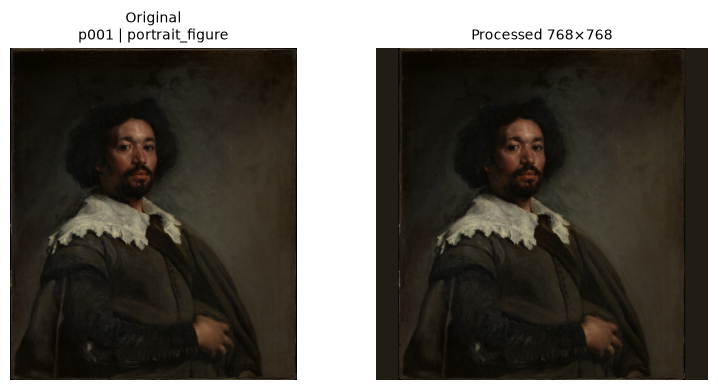

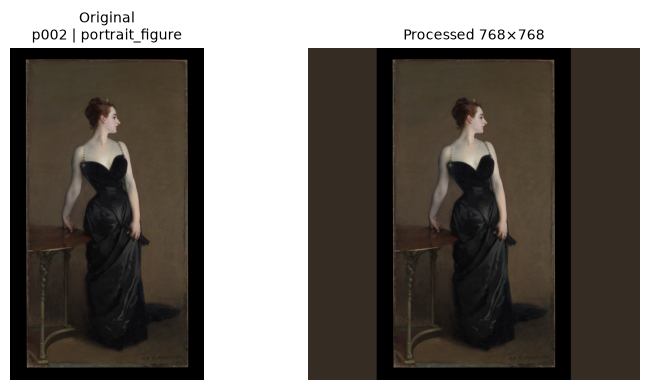

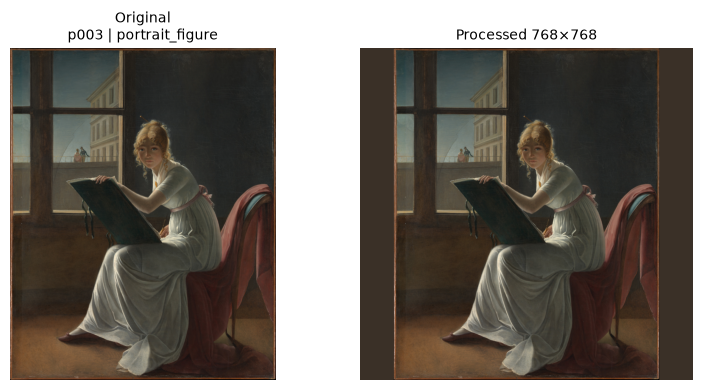

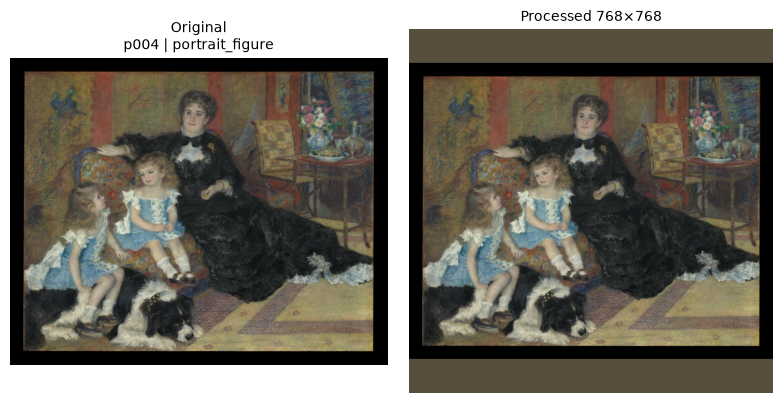

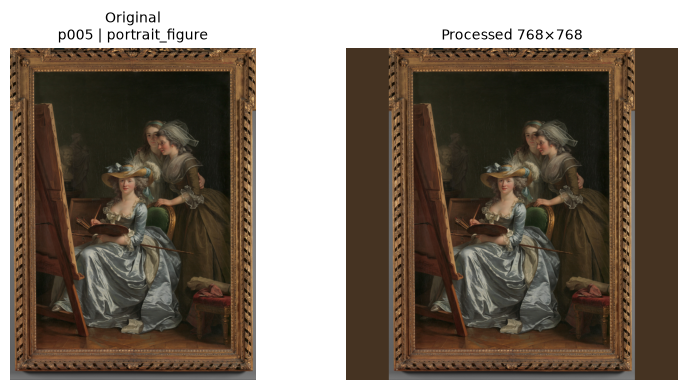

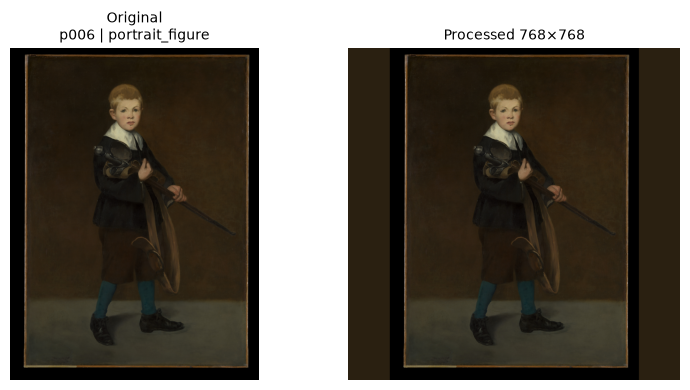

In [6]:
# Visual comparison preview

preview_limit = min(
    6,
    len(metadata_df),
)

preview_df = (
    metadata_df[
        [
            "painting_id",
            "category",
            "filename",
        ]
    ]
    .merge(
        processed_image_metadata_df[
            [
                "painting_id",
                "processed_filename",
            ]
        ],
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .head(preview_limit)
    .reset_index(drop=True)
)


for preview_row in preview_df.itertuples(
    index=False
):
    original_image_path = (
        raw_image_dir
        / preview_row.filename
    )

    processed_image_path = (
        clean_image_dir
        / preview_row.processed_filename
    )


    figure, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4),
    )


    with Image.open(
        original_image_path
    ) as original_image:
        axes[0].imshow(
            original_image.convert("RGB")
        )

    axes[0].set_title(
        "Original\n"
        f"{preview_row.painting_id} | "
        f"{preview_row.category}",
        fontsize=10,
    )

    axes[0].axis("off")


    with Image.open(
        processed_image_path
    ) as processed_image:
        axes[1].imshow(
            processed_image.convert("RGB")
        )

    axes[1].set_title(
        f"Processed {target_size}×{target_size}",
        fontsize=10,
    )

    axes[1].axis("off")


    plt.tight_layout()
    plt.show()
    plt.close(figure)

In [14]:
# Build canonical processed metadata

import numpy as np

processed_metadata_df = build_processed_metadata(
    metadata=metadata_df,
    processed_df=processed_image_metadata_df,
)


required_processed_metadata_columns = [
    "painting_id",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
    "target_size",
    "resize_scale",
    "resized_width",
    "resized_height",
    "pad_left",
    "pad_top",
    "pad_right",
    "pad_bottom",
    "padding_color_r",
    "padding_color_g",
    "padding_color_b",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
    "preprocessing_method",
]

missing_processed_metadata_columns = [
    column
    for column in required_processed_metadata_columns
    if column not in processed_metadata_df.columns
]

if missing_processed_metadata_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_metadata_columns}"
    )


processed_metadata_df["orientation"] = np.select(
    [
        processed_metadata_df["content_width"]
        > processed_metadata_df["content_height"],

        processed_metadata_df["content_height"]
        > processed_metadata_df["content_width"],
    ],
    [
        "landscape",
        "portrait",
    ],
    default="square",
)


processed_metadata_df[
    "content_area_pixels"
] = (
    processed_metadata_df[
        "content_width"
    ]
    * processed_metadata_df[
        "content_height"
    ]
)

processed_metadata_df[
    "canvas_area_pixels"
] = (
    processed_metadata_df[
        "target_size"
    ]
    ** 2
)

processed_metadata_df[
    "content_area_percentage"
] = (
    processed_metadata_df[
        "content_area_pixels"
    ]
    / processed_metadata_df[
        "canvas_area_pixels"
    ]
    * 100
).round(4)

processed_metadata_df[
    "padding_area_pixels"
] = (
    processed_metadata_df[
        "canvas_area_pixels"
    ]
    - processed_metadata_df[
        "content_area_pixels"
    ]
)

processed_metadata_df[
    "padding_area_percentage"
] = (
    100
    - processed_metadata_df[
        "content_area_percentage"
    ]
).round(4)


if (
    len(processed_metadata_df)
    != expected_painting_count
):
    raise ValueError(
        "Processed metadata row-count mismatch: "
        f"expected {expected_painting_count}, "
        f"found {len(processed_metadata_df)}"
    )


if processed_metadata_df[
    "painting_id"
].duplicated().any():
    duplicate_painting_ids = (
        processed_metadata_df.loc[
            processed_metadata_df[
                "painting_id"
            ].duplicated(
                keep=False
            ),
            "painting_id",
        ]
        .astype(str)
        .tolist()
    )

    raise ValueError(
        "Processed metadata contains duplicate painting IDs: "
        f"{sorted(set(duplicate_painting_ids))}"
    )


if processed_metadata_df[
    "processed_filename"
].duplicated().any():
    duplicate_processed_filenames = (
        processed_metadata_df.loc[
            processed_metadata_df[
                "processed_filename"
            ].duplicated(
                keep=False
            ),
            "processed_filename",
        ]
        .astype(str)
        .tolist()
    )

    raise ValueError(
        "Processed metadata contains duplicate output filenames: "
        f"{sorted(set(duplicate_processed_filenames))}"
    )


print("Processed metadata built.")

print(
    "Rows:",
    len(processed_metadata_df),
)

print(
    "Columns:",
    len(processed_metadata_df.columns),
)


print("\nKey preprocessing fields:")

display(
    processed_metadata_df[
        [
            "painting_id",
            "processed_filename",
            "processed_path",
            "resized_width",
            "resized_height",
            "pad_left",
            "pad_top",
            "pad_right",
            "pad_bottom",
            "content_area_percentage",
            "padding_area_percentage",
        ]
    ].head()
)

Processed metadata built.
Rows: 50
Columns: 47

Key preprocessing fields:


,painting_id,processed_filename,processed_path,resized_width,resized_height,pad_left,pad_top,pad_right,pad_bottom,content_area_percentage,padding_area_percentage
0,p001,p001_clean.png,data/processed/clean/p001_clean.png,663,768,52,0,53,0,86.3281,13.6719
1,p002,p002_clean.png,data/processed/clean/p002_clean.png,449,768,159,0,160,0,58.4635,41.5365
2,p003,p003_clean.png,data/processed/clean/p003_clean.png,614,768,77,0,77,0,79.9479,20.0521
3,p004,p004_clean.png,data/processed/clean/p004_clean.png,768,625,0,71,0,72,81.3802,18.6198
4,p005,p005_clean.png,data/processed/clean/p005_clean.png,569,768,99,0,100,0,74.0885,25.9115


In [15]:
# Validate processed clean images, geometry and padding

import numpy as np


preprocessing_validation_records = []


for processed_metadata_row in (
    processed_metadata_df.itertuples(
        index=False
    )
):
    painting_id = str(
        processed_metadata_row.painting_id
    )

    processed_image_path = (
        PROJECT_ROOT
        / Path(
            processed_metadata_row.processed_path
        )
    )


    file_exists = (
        processed_image_path.is_file()
    )

    image_readable = False
    image_width = None
    image_height = None
    image_mode = None
    image_format = None

    padding_geometry_valid = False
    content_box_valid = False
    geometry_valid = False
    padding_color_valid = False

    validation_issues = []


    if not file_exists:
        validation_issues.append(
            "missing_processed_file"
        )

    else:
        try:
            with Image.open(
                processed_image_path
            ) as processed_image:
                processed_image.verify()


            with Image.open(
                processed_image_path
            ) as processed_image:
                processed_image.load()

                image_readable = True

                image_width, image_height = (
                    processed_image.size
                )

                image_mode = (
                    processed_image.mode
                )

                image_format = (
                    processed_image.format
                )

                processed_image_array = np.asarray(
                    processed_image.convert(
                        "RGB"
                    )
                )

        except Exception as exc:
            validation_issues.append(
                "unreadable_processed_file:"
                f"{type(exc).__name__}"
            )


    if image_readable:
        if (
            image_width != target_size
            or image_height != target_size
        ):
            validation_issues.append(
                "wrong_processed_size"
            )


        if image_mode != "RGB":
            validation_issues.append(
                "wrong_color_mode"
            )


        if image_format != "PNG":
            validation_issues.append(
                "wrong_image_format"
            )


        padding_geometry_valid = bool(
            processed_metadata_row.pad_left
            + processed_metadata_row.resized_width
            + processed_metadata_row.pad_right
            == processed_metadata_row.target_size
            and
            processed_metadata_row.pad_top
            + processed_metadata_row.resized_height
            + processed_metadata_row.pad_bottom
            == processed_metadata_row.target_size
        )

        if not padding_geometry_valid:
            validation_issues.append(
                "invalid_padding_geometry"
            )


        content_box_valid = bool(
            processed_metadata_row.content_x_min
            == processed_metadata_row.pad_left
            and
            processed_metadata_row.content_y_min
            == processed_metadata_row.pad_top
            and
            processed_metadata_row.content_x_max
            == (
                processed_metadata_row.pad_left
                + processed_metadata_row.resized_width
            )
            and
            processed_metadata_row.content_y_max
            == (
                processed_metadata_row.pad_top
                + processed_metadata_row.resized_height
            )
            and
            processed_metadata_row.content_width
            == processed_metadata_row.resized_width
            and
            processed_metadata_row.content_height
            == processed_metadata_row.resized_height
            and
            (
                processed_metadata_row.content_x_max
                - processed_metadata_row.content_x_min
            )
            == processed_metadata_row.content_width
            and
            (
                processed_metadata_row.content_y_max
                - processed_metadata_row.content_y_min
            )
            == processed_metadata_row.content_height
            and
            0
            <= processed_metadata_row.content_x_min
            < processed_metadata_row.content_x_max
            <= processed_metadata_row.target_size
            and
            0
            <= processed_metadata_row.content_y_min
            < processed_metadata_row.content_y_max
            <= processed_metadata_row.target_size
        )

        if not content_box_valid:
            validation_issues.append(
                "invalid_content_box"
            )


        geometry_valid = bool(
            padding_geometry_valid
            and content_box_valid
        )


        expected_padding_rgb = np.array(
            [
                processed_metadata_row.padding_color_r,
                processed_metadata_row.padding_color_g,
                processed_metadata_row.padding_color_b,
            ],
            dtype=np.uint8,
        )


        padding_regions = []


        if processed_metadata_row.pad_top > 0:
            padding_regions.append(
                processed_image_array[
                    : processed_metadata_row.pad_top,
                    :,
                    :,
                ]
            )


        if processed_metadata_row.pad_bottom > 0:
            padding_regions.append(
                processed_image_array[
                    processed_metadata_row.content_y_max :,
                    :,
                    :,
                ]
            )


        if processed_metadata_row.pad_left > 0:
            padding_regions.append(
                processed_image_array[
                    processed_metadata_row.content_y_min :
                    processed_metadata_row.content_y_max,
                    : processed_metadata_row.pad_left,
                    :,
                ]
            )


        if processed_metadata_row.pad_right > 0:
            padding_regions.append(
                processed_image_array[
                    processed_metadata_row.content_y_min :
                    processed_metadata_row.content_y_max,
                    processed_metadata_row.content_x_max :,
                    :,
                ]
            )


        if padding_regions:
            padding_color_valid = all(
                np.all(
                    padding_region
                    == expected_padding_rgb
                )
                for padding_region
                in padding_regions
            )

        else:
            padding_color_valid = True


        if not padding_color_valid:
            validation_issues.append(
                "padding_color_mismatch"
            )


    preprocessing_validation_records.append(
        {
            "painting_id": painting_id,
            "processed_path": (
                processed_metadata_row.processed_path
            ),
            "file_exists": file_exists,
            "image_readable": image_readable,
            "image_width": image_width,
            "image_height": image_height,
            "image_mode": image_mode,
            "image_format": image_format,
            "padding_geometry_valid": (
                padding_geometry_valid
            ),
            "content_box_valid": (
                content_box_valid
            ),
            "geometry_valid": (
                geometry_valid
            ),
            "padding_color_valid": (
                padding_color_valid
            ),
            "issue": ";".join(
                validation_issues
            ),
        }
    )


preprocessing_validation_df = pd.DataFrame(
    preprocessing_validation_records
)


preprocessing_validation_summary = {
    "rows_checked": len(
        preprocessing_validation_df
    ),
    "missing_files": int(
        (
            ~preprocessing_validation_df[
                "file_exists"
            ]
        ).sum()
    ),
    "unreadable_files": int(
        (
            ~preprocessing_validation_df[
                "image_readable"
            ]
        ).sum()
    ),
    "invalid_geometry": int(
        (
            ~preprocessing_validation_df[
                "geometry_valid"
            ]
        ).sum()
    ),
    "invalid_padding_color": int(
        (
            ~preprocessing_validation_df[
                "padding_color_valid"
            ]
        ).sum()
    ),
    "validation_issues": int(
        preprocessing_validation_df[
            "issue"
        ]
        .ne("")
        .sum()
    ),
}


print("Processed output validation:")

for (
    validation_name,
    validation_value,
) in preprocessing_validation_summary.items():
    print(
        f"  {validation_name}: "
        f"{validation_value}"
    )


print("\nImage formats:")

display(
    preprocessing_validation_df[
        "image_format"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "image_format"
    )
    .reset_index(
        name="count"
    )
)


print("\nImage modes:")

display(
    preprocessing_validation_df[
        "image_mode"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "image_mode"
    )
    .reset_index(
        name="count"
    )
)


failed_preprocessing_validation_df = (
    preprocessing_validation_df.loc[
        preprocessing_validation_df[
            "issue"
        ].ne("")
    ]
    .copy()
)


if not failed_preprocessing_validation_df.empty:
    display(
        failed_preprocessing_validation_df
    )

    raise ValueError(
        "Processed output validation failed "
        f"for "
        f"{len(failed_preprocessing_validation_df)} "
        "images."
    )


print(
    "\nAll processed clean images passed "
    "file, geometry and padding validation."
)

Processed output validation:
  rows_checked: 50
  missing_files: 0
  unreadable_files: 0
  invalid_geometry: 0
  invalid_padding_color: 0
  validation_issues: 0

Image formats:


,image_format,count
0,PNG,50



Image modes:


,image_mode,count
0,RGB,50



All processed clean images passed file, geometry and padding validation.


In [16]:
# Save canonical processed metadata

processed_metadata_dir.mkdir(
    parents=True,
    exist_ok=True,
)

processed_metadata_df.to_csv(
    processed_metadata_path,
    index=False,
)

print(
    "Canonical processed metadata saved:"
)

print(
    processed_metadata_path.relative_to(
        PROJECT_ROOT
    )
)

print(
    "\nRows:",
    len(processed_metadata_df),
)

print(
    "Columns:",
    len(processed_metadata_df.columns),
)

display(
    processed_metadata_df.head()
)

Canonical processed metadata saved:
data\processed\metadata\metadata_processed_clean.csv

Rows: 50
Columns: 47


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


In [17]:
# Build preprocessing audit

preprocessing_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

preprocessing_audit_records = [
    {
        "check": "processed_rows",
        "value": len(processed_metadata_df),
    },
    {
        "check": "expected_rows",
        "value": expected_painting_count,
    },
    {
        "check": "target_size",
        "value": target_size,
    },
    {
        "check": "mean_resize_scale",
        "value": round(
            processed_metadata_df[
                "resize_scale"
            ].mean(),
            6,
        ),
    },
    {
        "check": "mean_content_area_percent",
        "value": round(
            processed_metadata_df[
                "content_area_percentage"
            ].mean(),
            4,
        ),
    },
    {
        "check": "mean_padding_area_percent",
        "value": round(
            processed_metadata_df[
                "padding_area_percentage"
            ].mean(),
            4,
        ),
    },
    {
        "check": "minimum_content_area_percent",
        "value": round(
            processed_metadata_df[
                "content_area_percentage"
            ].min(),
            4,
        ),
    },
    {
        "check": "maximum_content_area_percent",
        "value": round(
            processed_metadata_df[
                "content_area_percentage"
            ].max(),
            4,
        ),
    },
    {
        "check": "validation_passed",
        "value": (
            failed_preprocessing_validation_df.empty
        ),
    },
]

preprocessing_audit_df = pd.DataFrame(
    preprocessing_audit_records
)

preprocessing_audit_df.to_csv(
    preprocessing_audit_path,
    index=False,
)

print(
    "Saved preprocessing audit:"
)

print(
    preprocessing_audit_path.relative_to(
        PROJECT_ROOT
    )
)

display(
    preprocessing_audit_df
)

Saved preprocessing audit:
outputs\02_preprocessing\preprocessing_audit.csv


,check,value
0,processed_rows,50
1,expected_rows,50
2,target_size,768
3,mean_resize_scale,0.203642
4,mean_content_area_percent,77.0833
5,mean_padding_area_percent,22.9167
6,minimum_content_area_percent,56.6406
7,maximum_content_area_percent,100.0
8,validation_passed,True


In [18]:
# Summary tables (display only)

print(
    "Content area by category"
)

display(
    processed_metadata_df
    .groupby(
        "category",
        observed=False,
    )[
        [
            "content_area_percentage",
            "padding_area_percentage",
        ]
    ]
    .agg(
        [
            "mean",
            "min",
            "max",
        ]
    )
    .round(2)
)


print(
    "\nOrientation distribution"
)

display(
    processed_metadata_df[
        "orientation"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "orientation"
    )
    .reset_index(
        name="count"
    )
)


print(
    "\nMost padded paintings"
)

display(
    processed_metadata_df[
        [
            "painting_id",
            "category",
            "padding_area_percentage",
            "content_area_percentage",
        ]
    ]
    .sort_values(
        "padding_area_percentage",
        ascending=False,
    )
    .head(10)
)

Content area by category


content_area_percentage                 \
                                           mean    min     max   
category                                                         
abstraction_surrealism                    85.86  69.01  100.00   
architecture_structured                   74.22  64.97   84.51   
high_texture_brushwork                    77.79  62.89   92.71   
landscape_natural                         70.03  56.64   87.63   
portrait_figure                           77.53  58.46   90.49   

                        padding_area_percentage                
                                           mean    min    max  
category                                                       
abstraction_surrealism                    14.14   0.00  30.99  
architecture_structured                   25.78  15.49  35.03  
high_texture_brushwork                    22.21   7.29  37.11  
landscape_natural                         29.97  12.37  43.36  
portrait_figure                           22.47   9.51  41.54


Orientation distribution


,orientation,count
0,landscape,26
1,portrait,23
2,square,1



Most padded paintings


,painting_id,category,padding_area_percentage,content_area_percentage
13,p014,landscape_natural,43.3594,56.6406
1,p002,portrait_figure,41.5365,58.4635
48,p049,high_texture_brushwork,37.1094,62.8906
15,p016,landscape_natural,36.8490,63.1510
41,p042,high_texture_brushwork,35.6771,64.3229
28,p029,architecture_structured,35.0260,64.9740
29,p030,architecture_structured,34.2448,65.7552
17,p018,landscape_natural,33.9844,66.0156
10,p011,landscape_natural,31.2500,68.7500
25,p026,architecture_structured,31.1198,68.8802


In [19]:
print("=" * 80)
print("Notebook 02 completed successfully.")
print("=" * 80)

print("\nCanonical outputs")

print(
    f"• Clean images: {clean_image_dir.relative_to(PROJECT_ROOT)}"
)

print(
    f"• Processed metadata: {processed_metadata_path.relative_to(PROJECT_ROOT)}"
)

print(
    f"• Preprocessing audit: {preprocessing_audit_path.relative_to(PROJECT_ROOT)}"
)

print("\nNext notebook:")

print(
    "03_mask_generation.ipynb"
)

Notebook 02 completed successfully.

Canonical outputs
• Clean images: data\processed\clean
• Processed metadata: data\processed\metadata\metadata_processed_clean.csv
• Preprocessing audit: outputs\02_preprocessing\preprocessing_audit.csv

Next notebook:
03_mask_generation.ipynb


# Summary

## Purpose

This notebook standardizes the raw painting collection into a deterministic dataset suitable for all subsequent restoration experiments. Every painting is resized while preserving its aspect ratio, centered on a fixed square canvas using median-color padding, and accompanied by standardized metadata describing the preprocessing operation.

## Inputs

- Verified raw images from Notebook 01
- Dataset metadata
- Experiment configuration (`experiment_50_config.yaml`)

## Processing performed

- Validated Notebook 01 outputs before execution
- Resized every image while preserving aspect ratio
- Applied median RGB padding to obtain a fixed **768 × 768** canvas
- Recorded resize scale, padding dimensions, padding colour and content bounding box
- Generated standardized processed images
- Performed validation of:
  - image existence
  - readability
  - dimensions
  - RGB colour mode
  - PNG format
  - padding geometry
  - content bounding boxes
  - padding colour consistency

## Canonical outputs

### Processed images

```
data/processed/clean/
```

### Processed metadata

```
data/processed/metadata/metadata_processed_clean.csv
```

### Audit report

```
outputs/02_preprocessing/preprocessing_audit.csv
```

## Notes

- All processed images have identical spatial dimensions (768 × 768 pixels).
- Aspect ratio is preserved for every painting.
- Padding is deterministic and reproducible through median RGB estimation.
- Content bounding boxes produced here are reused throughout subsequent notebooks for mask generation, restoration, metric computation and evaluation.
- Summary tables shown within this notebook are generated directly from the canonical metadata and are therefore not stored as separate artifacts.

## Next notebook

**Notebook 03 — Mask Generation**

The next stage generates deterministic artificial damage masks constrained to the detected painting content region.